# VenusREM & ProSST zero-shot substitution matrices

Runs **ProSST-2048** and **VenusREM** (ProSST logits blended with a Foldseek structure-alignment profile) on a single protein structure and produces, for each model, a 2D zero-shot score matrix of shape `(protein_length, 20)`:

- rows = positions along the protein (1-indexed, in structure order)
- columns = the 20 canonical amino acids, in a fixed order
- `matrix[i, j] = log P(aa_j | position i) - log P(wildtype_i | position i)`

This is exactly the per-mutation score these models report (see `src/tools/mutation/models/prosst.py` and `src/tools/mutation/models/venusrem.py`), just computed for *all* positions x amino acids at once instead of for a specific mutant list.

Example structure: `example/file/convert/cas12i3.cif` (a pre-converted `cas12i3.pdb` also ships next to it, since ProSST's structure-token pipeline requires PDB format).

In [1]:
import sys
from pathlib import Path

_REPO_ROOT = next((p for p in Path.cwd().resolve().parents if (p / "src").is_dir()), Path.cwd().resolve())
if not (_REPO_ROOT / "src").is_dir():
    _REPO_ROOT = Path.cwd().resolve()
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

print(f"Repo root: {_REPO_ROOT}")

Repo root: /Users/kolya/PycharmProjects/VenusFactory2


In [2]:
import os
import numpy as np
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer

from src.tools.train.data.prosst.structure.get_sst_seq import SSTPredictor
from src.tools.mutation.models.esm.inverse_folding.util import extract_seq_from_pdb, load_structure
from src.tools.mutation.models.venusrem import process_pdb, read_multi_fasta, count_matrix_from_structure_alignment

# The 20 canonical amino acids, fixed column order for both matrices
AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')

## Configuration

In [3]:
#STRUCTURE_FILE = str(_REPO_ROOT / "example" / "file" / "convert" / "cas12i3.cif")

CHAIN_ID = "A"
ALPHA = 0.8  # VenusREM weight for the Foldseek structure-alignment profile
OUTPUT_DIR = _REPO_ROOT / "example" / "mutation" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Structure file: {STRUCTURE_FILE}")
print(f"Using device: {device}")

Structure file: /Users/kolya/PycharmProjects/VenusFactory2/example/file/convert/cas12i3.cif
Using device: cpu


## Make sure we have a `.pdb` file

ProSST's structure-graph pipeline (`Bio.PDB.PDBParser`) only reads legacy PDB format, so a `.cif` input is converted to `.pdb` first. If a same-named `.pdb` already sits next to the `.cif` (as with the bundled example), it's reused as-is.

In [4]:
def ensure_pdb_file(structure_file: str, chain_id: str = "A") -> str:
    if structure_file.endswith(".pdb"):
        return structure_file

    candidate = str(Path(structure_file).with_suffix(".pdb"))
    if os.path.exists(candidate):
        print(f">>> Reusing existing converted file: {candidate}")
        return candidate

    from biotite.structure.io import pdb as biotite_pdb

    print(f">>> Converting {structure_file} -> {candidate}")
    structure = load_structure(structure_file, chain_id)
    pdb_file = biotite_pdb.PDBFile()
    pdb_file.set_structure(structure)
    pdb_file.write(candidate)
    return candidate


pdb_file = ensure_pdb_file(STRUCTURE_FILE, CHAIN_ID)
print(f"PDB file used for scoring: {pdb_file}")

>>> Reusing existing converted file: /Users/kolya/PycharmProjects/VenusFactory2/example/file/convert/cas12i3.pdb
PDB file used for scoring: /Users/kolya/PycharmProjects/VenusFactory2/example/file/convert/cas12i3.pdb


## Load ProSST and compute per-position log-probabilities

In [5]:
print(">>> Loading ProSST model and tokenizer...")
prosst_model = AutoModelForMaskedLM.from_pretrained("AI4Protein/ProSST-2048", trust_remote_code=True).to(device)
prosst_tokenizer = AutoTokenizer.from_pretrained("AI4Protein/ProSST-2048", trust_remote_code=True)
predictor = SSTPredictor(structure_vocab_size=2048)
vocab = prosst_tokenizer.get_vocab()

print(">>> Extracting structure tokens from PDB...")
structure_sequence = predictor.predict_from_pdb(pdb_file)[0]["2048_sst_seq"]
structure_sequence_offset = [i + 3 for i in structure_sequence]

print(">>> Extracting residue sequence from PDB...")
residue_sequence = extract_seq_from_pdb(pdb_file, CHAIN_ID)
print(f">>> Protein length: {len(residue_sequence)}")

tokenized_res = prosst_tokenizer([residue_sequence], return_tensors="pt")
input_ids = tokenized_res["input_ids"].to(device)
attention_mask = tokenized_res["attention_mask"].to(device)
structure_input_ids = torch.tensor([1, *structure_sequence_offset, 2], dtype=torch.long).unsqueeze(0).to(device)

print(">>> Computing ProSST logits...")
with torch.no_grad():
    outputs = prosst_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        ss_input_ids=structure_input_ids,
    )
prosst_logits = torch.log_softmax(outputs.logits[:, 1:-1], dim=-1).squeeze(0)
print(f">>> ProSST logits shape: {tuple(prosst_logits.shape)}")

>>> Loading ProSST model and tokenizer...
---------- Load Model on cpu ----------
MODEL: 5.90M parameters
>>> Extracting structure tokens from PDB...
---------- Building Subgraphs ----------


100%|██████████| 1/1 [00:21<00:00, 21.78s/it]


>>> Extracting residue sequence from PDB...
>>> Protein length: 1045
>>> Computing ProSST logits...
>>> ProSST logits shape: (1045, 25)


## Build the ProSST zero-shot score matrix

`matrix[i, j] = log P(AMINO_ACIDS[j] | position i) - log P(wildtype residue at i | position i)`

In [6]:
def build_score_matrix(logits: torch.Tensor, residue_sequence: str, vocab: dict, amino_acids=AMINO_ACIDS) -> np.ndarray:
    """logits: [seq_len, vocab_size] log-probabilities -> [seq_len, len(amino_acids)] zero-shot scores"""
    logits_np = logits.detach().cpu().numpy()
    aa_cols = np.array([vocab[aa] for aa in amino_acids])
    wt_rows = np.array([vocab[wt] for wt in residue_sequence])

    scores = logits_np[:, aa_cols]                 # [seq_len, 20]
    wt_logits = logits_np[np.arange(len(residue_sequence)), wt_rows]  # [seq_len]
    return scores - wt_logits[:, None]


prosst_matrix = build_score_matrix(prosst_logits, residue_sequence, vocab)
print(f">>> ProSST score matrix shape: {prosst_matrix.shape}  (positions x amino acids)")

>>> ProSST score matrix shape: (1045, 20)  (positions x amino acids)


## VenusREM: blend ProSST logits with a Foldseek structure-alignment profile

This submits the structure to the public Foldseek search API and needs network access; if it is unavailable or returns no alignments, VenusREM falls back to plain ProSST logits (matching `venusrem_score` in `src/tools/mutation/models/venusrem.py`).

In [7]:
venusrem_logits = prosst_logits

print(">>> Submitting to Foldseek for structure alignment...")
foldseek_dir = OUTPUT_DIR / "foldseek_alignments"
fasta_path = process_pdb(pdb_file, str(foldseek_dir))

if fasta_path is not None:
    alignment_dict = read_multi_fasta(fasta_path)
    if len(alignment_dict) > 0:
        print(f">>> Processing {len(alignment_dict)} structure alignments...")
        count_matrix = count_matrix_from_structure_alignment(prosst_tokenizer, alignment_dict, device)
        if count_matrix is not None and count_matrix.size(0) == prosst_logits.size(0):
            print(f">>> Combining ProSST logits with structure alignment (alpha={ALPHA})...")
            venusrem_logits = (1 - ALPHA) * prosst_logits + ALPHA * count_matrix
        else:
            print(">>> Dimension mismatch or empty count matrix, using ProSST logits only")
    else:
        print(">>> No valid alignments found, using ProSST logits only")
else:
    print(">>> No Foldseek alignment available, using ProSST logits only")

venusrem_matrix = build_score_matrix(venusrem_logits, residue_sequence, vocab)
print(f">>> VenusREM score matrix shape: {venusrem_matrix.shape}  (positions x amino acids)")

>>> Submitting to Foldseek for structure alignment...
>>> Submitting to FoldSeek...
>>> Job submitted: d07qOSD45XnoWgvhOYGWrlO1I5u1VFeO-yqWjQ, waiting for completion...
>>> Downloading alignments...
>>> cas12i3 done, saved 6 unique alignments
>>> Processing 6 structure alignments...
>>> Start tokenizing 6 structure alignment sequences
>>> Counting amino acid distribution at each position


100%|██████████| 255/255 [00:00<00:00, 168432.68it/s]

>>> Dimension mismatch or empty count matrix, using ProSST logits only
>>> VenusREM score matrix shape: (1045, 20)  (positions x amino acids)


## Save the matrices

In [8]:
protein_name = Path(STRUCTURE_FILE).stem

np.save(OUTPUT_DIR / f"{protein_name}_prosst_matrix.npy", prosst_matrix)
np.save(OUTPUT_DIR / f"{protein_name}_venusrem_matrix.npy", venusrem_matrix)

with open(OUTPUT_DIR / f"{protein_name}_matrix_labels.txt", "w") as f:
    f.write("columns(amino_acids): " + ",".join(AMINO_ACIDS) + "\n")
    f.write("rows(1-indexed wildtype): " + ",".join(f"{wt}{i+1}" for i, wt in enumerate(residue_sequence)) + "\n")

print(f">>> Saved matrices and labels to {OUTPUT_DIR}")
print(f"    {protein_name}_prosst_matrix.npy    shape={prosst_matrix.shape}")
print(f"    {protein_name}_venusrem_matrix.npy  shape={venusrem_matrix.shape}")

>>> Saved matrices and labels to /Users/kolya/PycharmProjects/VenusFactory2/example/mutation/output
    cas12i3_prosst_matrix.npy    shape=(1045, 20)
    cas12i3_venusrem_matrix.npy  shape=(1045, 20)


## (Optional) Quick heatmap preview

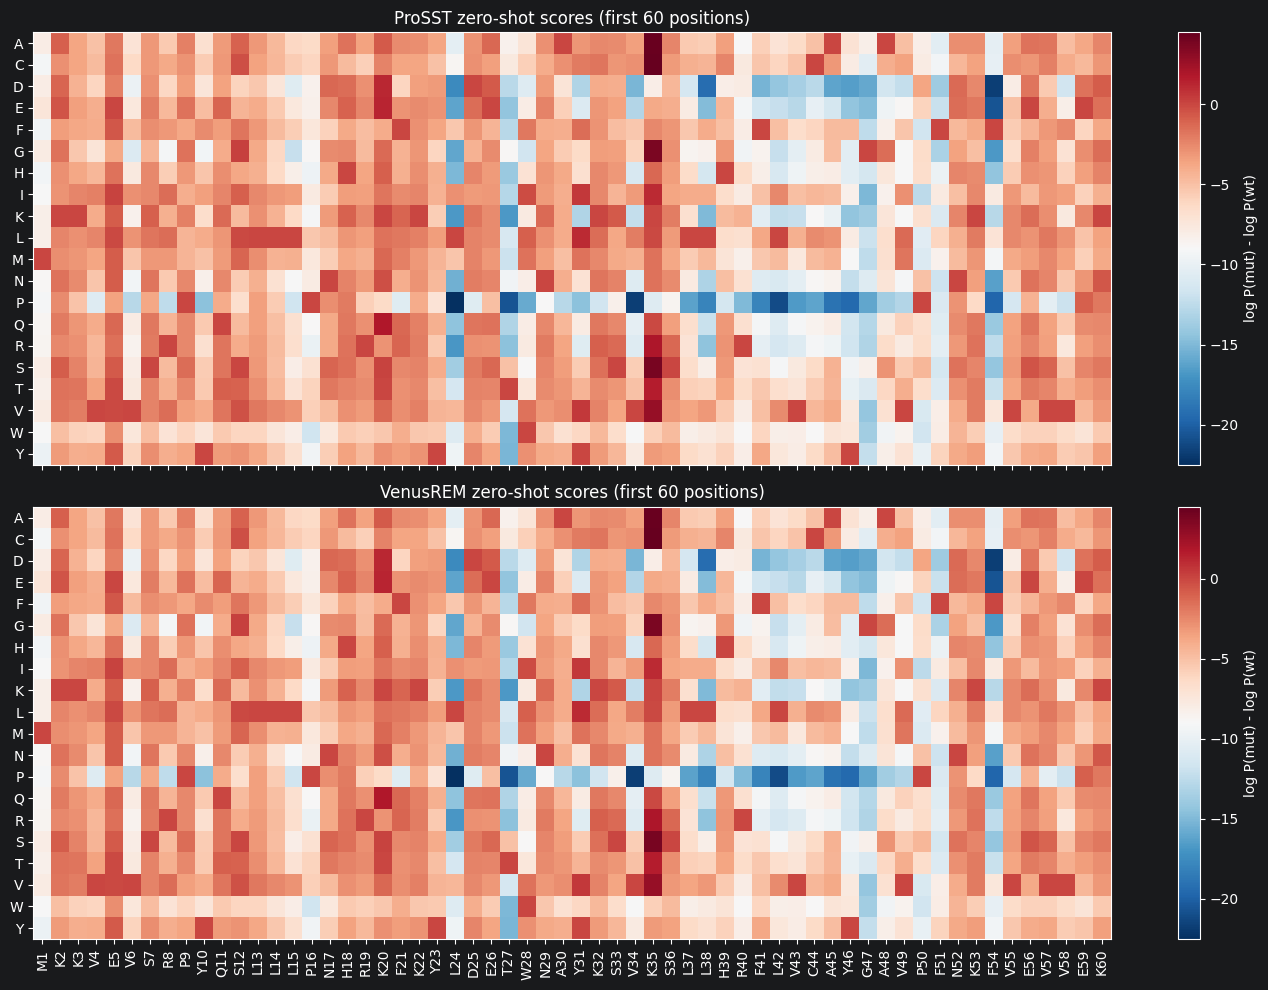

In [9]:
import matplotlib.pyplot as plt

window = slice(0, min(60, len(residue_sequence)))

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
for ax, matrix, title in zip(axes, [prosst_matrix, venusrem_matrix], ["ProSST", "VenusREM"]):
    im = ax.imshow(matrix[window].T, aspect="auto", cmap="RdBu_r")
    ax.set_yticks(range(len(AMINO_ACIDS)))
    ax.set_yticklabels(AMINO_ACIDS)
    ax.set_xticks(range(window.stop - window.start))
    ax.set_xticklabels([f"{wt}{i+1}" for i, wt in enumerate(residue_sequence[window], start=window.start)], rotation=90)
    ax.set_title(f"{title} zero-shot scores (first {window.stop} positions)")
    fig.colorbar(im, ax=ax, label="log P(mut) - log P(wt)")
plt.tight_layout()
plt.show()